# Packed tubes

Packed beds in narrow tubes are common in chemical reactors, and the wall changes the structure: next to the wall the spheres order in layers, and the porosity oscillates over a few diameters. This notebook packs spheres in cylinders and computes the radial porosity profile.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import spheropack as sp
from spheropack import analysis
from spheropack.plotting import plot_section

## A tube packed to jamming

`Cylinder(diameter, length)` is periodic along its axis (z by default), which models a section of a long tube without end effects; `capped=True` closes it with flat walls. Here the tube diameter is 7 sphere diameters. The number of spheres is chosen for a length of about 10 diameters at a solid fraction of 0.6; with `density="max"` the length stays fixed and the spheres grow until they jam.

In [2]:
d, ratio, length = 1.0, 7.0, 10.0
D = ratio * d
tube = sp.Cylinder(diameter=D, length=length)
n = round(0.6 * tube.volume / (math.pi / 6 * d**3))
p = sp.pack(n=n, density="max", container=tube, seed=1)
print(p)
print(f"mean sphere diameter {p.diameters.mean():.4f}, porosity {1 - p.density:.4f}")

Packing(n=441, dim=3, density=0.597426, status='jammed', reduced_pressure=1.03e+09, n_collisions=1822422, seed=1)
mean sphere diameter 0.9986, porosity 0.4026


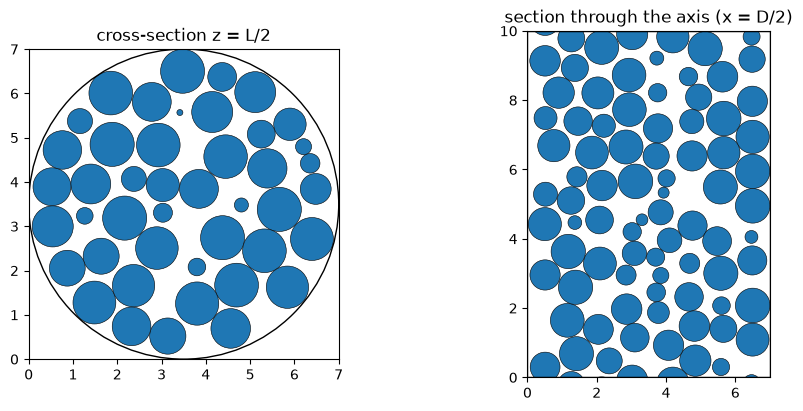

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [1, 1.5]})
plot_section(p, axis=2, ax=axes[0])
axes[0].set_title("cross-section z = L/2")
plot_section(p, axis=0, ax=axes[1])
axes[1].set_title("section through the axis (x = D/2)");

## Radial porosity profile

`analysis.radial_profile` computes the solid fraction on cylinder surfaces at distance $r$ from the axis, exactly from the sphere geometry. The porosity $\varepsilon = 1 - \phi$ is 1 at the wall, where spheres touch it only in points, and oscillates with a period of somewhat less than a diameter; the oscillations decay towards the centre. Wall effects are stronger in narrower tubes.

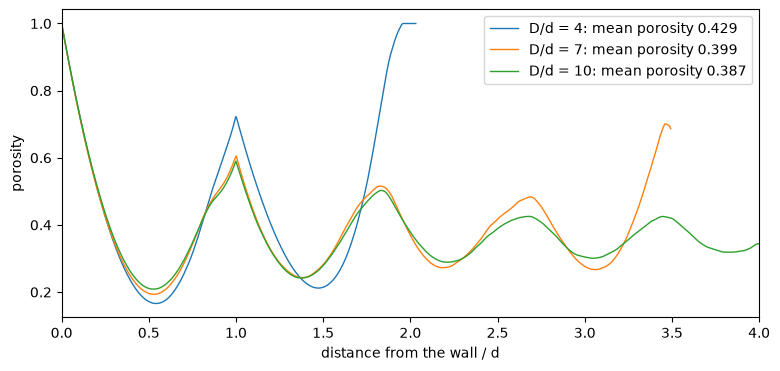

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for ratio in (4.0, 7.0, 10.0):
    tube = sp.Cylinder(diameter=ratio * d, length=length)
    n = round(0.6 * tube.volume / (math.pi / 6 * d**3))
    q = sp.pack(n=n, density="max", container=tube, seed=2)
    r, phi = analysis.radial_profile(q, bins=400)
    dm = q.diameters.mean()
    ax.plot((tube.ball.radius - r) / dm, 1 - phi, lw=1, label=f"D/d = {ratio:g}: mean porosity {1 - q.density:.3f}")
ax.set_xlim(0, 4)
ax.set_xlabel("distance from the wall / d"); ax.set_ylabel("porosity"); ax.legend();

The first minimum of the porosity lies half a diameter from the wall, where the centres of the wall layer sit. The mean porosity rises as the tube gets narrower, because the wall layer takes a larger share of the cross-section. Near the axis the cylinder surfaces become small, so the profile of a single packing is noisy there (the rise of the curves at the right end).

## Statistics over several packings

A single packing of a short tube is noisy. Averaging profiles of independent packings (different seeds) gives smooth curves; packing a longer tube does the same.

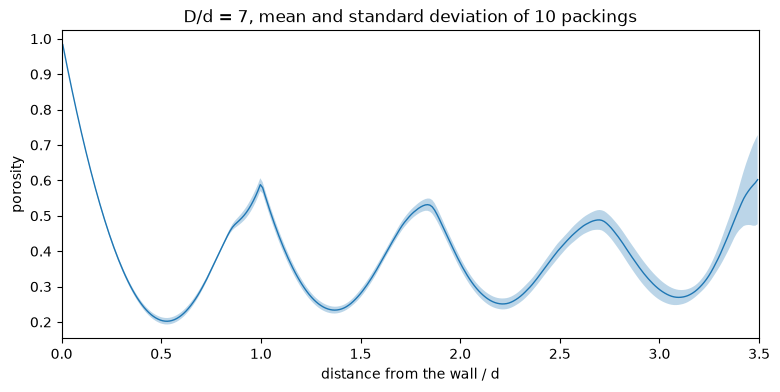

In [5]:
ratio = 7.0
tube = sp.Cylinder(diameter=ratio * d, length=length)
n = round(0.6 * tube.volume / (math.pi / 6 * d**3))
profiles = []
for seed in range(10, 20):
    q = sp.pack(n=n, density="max", container=tube, seed=seed)
    r, phi = analysis.radial_profile(q, bins=300)
    profiles.append(1 - phi)
profiles = np.array(profiles)
x = (tube.ball.radius - r) / q.diameters.mean()
plt.figure(figsize=(9, 4))
plt.fill_between(x, profiles.mean(0) - profiles.std(0), profiles.mean(0) + profiles.std(0), alpha=0.3)
plt.plot(x, profiles.mean(0), lw=1)
plt.xlabel("distance from the wall / d"); plt.ylabel("porosity"); plt.xlim(0, 3.5)
plt.title("D/d = 7, mean and standard deviation of 10 packings");

## Target density and the legacy tool

Packings at a prescribed density (below jamming) work the same way. The legacy command-line tool `generate_packed_tube` is available as `spheropack legacy-tube` with the same options and output format; from Python the equivalent is:

In [6]:
part_diam, tube_diam = 3e-3, 21e-3
n = 725
tube_length = n * (math.pi / 6) * part_diam**3 / 0.54 / (0.25 * math.pi * tube_diam**2)
t = sp.pack(n=n, radii=part_diam / 2, density=0.54, container=sp.Cylinder(tube_diam, tube_length),
            growth_rate=0.16, seed=1)
print(t)
t.to_csv("tube.csv", legacy_order=True)   # z,x,y,r without header, as the legacy tool
print(open("tube.csv").readline())

Packing(n=725, dim=3, density=0.54, status='target', reduced_pressure=45.7, n_collisions=36286, seed=1)
0.050532694821893452,0.015709305606754632,0.0040840491026851904,0.0015

